In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

# 경로
base_path = r"C:\Users\user\Desktop\데이터 분석 7기 자료\파이널프로젝트\멋사 Final_Project_env\data"

# 파일명 (전처리 노트북에서 저장한 파일)
file_refined = os.path.join(base_path, "refined_h7.csv")
file_refined30 = os.path.join(base_path, "refined_h7_30.csv")

# 로드
refined = pd.read_csv(file_refined, encoding="utf-8-sig")
refined_30 = pd.read_csv(file_refined30, encoding="utf-8-sig")

print("refined   :", refined.shape)
print("refined_30:", refined_30.shape)
print("\ncolumns:", refined_30.columns.tolist())

refined   : (102342, 20)
refined_30: (101373, 20)

columns: ['store_id', 'reviewer_id', 'visit_date', 'visit_count', 'visit_time', 'dow', 'day_type', 'store_group', 'is_weekday', 'is_weekend', 'is_morning', 'is_lunch', 'is_evening', 'is_weekday_morning', 'is_weekday_lunch', 'is_weekday_evening', 'is_weekend_morning', 'is_weekend_lunch', 'is_weekend_evening', 'n_reviews']


In [3]:
# EDA용 핵심 컬럼 확인
must_cols = ["store_id", "store_group", "day_type", "visit_time"]

for c in must_cols:
    print(f"{c}: {c in refined_30.columns}")

print("\n[store_group 분포]")
print(refined_30["store_group"].value_counts(dropna=False))

print("\n[day_type 분포]")
print(refined_30["day_type"].value_counts(dropna=False))

print("\n[visit_time 분포]")
print(refined_30["visit_time"].value_counts(dropna=False))

store_id: True
store_group: True
day_type: True
visit_time: True

[store_group 분포]
store_group
일반     98243
리저브     3130
Name: count, dtype: int64

[day_type 분포]
day_type
주중    68003
주말    33370
Name: count, dtype: int64

[visit_time 분포]
visit_time
점심    62103
저녁    23309
아침    15961
Name: count, dtype: int64


In [4]:
# 3. (안전장치) 값 표준화 + 파생변수 재생성 함수
def prepare_h7_df(df):
    x = df.copy()

    # 값 통일
    x["store_group"] = x["store_group"].astype(str).str.strip().replace({
        "general": "일반", "reserve": "리저브",
        "일반 매장": "일반", "리저브 매장": "리저브",
        "일반": "일반", "리저브": "리저브"
    })

    x["day_type"] = x["day_type"].astype(str).str.strip().replace({
        "weekday": "주중", "weekend": "주말",
        "주중": "주중", "주말": "주말"
    })

    x["visit_time"] = x["visit_time"].astype(str).str.strip().replace({
        "오전": "아침", "AM": "아침", "am": "아침", "morning": "아침",
        "오후": "점심", "lunch": "점심", "afternoon": "점심",
        "밤": "저녁", "PM": "저녁", "pm": "저녁", "dinner": "저녁", "evening": "저녁",
        "아침": "아침", "점심": "점심", "저녁": "저녁"
    })

    # 분석대상 필터
    x = x[x["store_group"].isin(["일반", "리저브"])].copy()
    x = x[x["day_type"].isin(["주중", "주말"])].copy()
    x = x[x["visit_time"].isin(["아침", "점심", "저녁"])].copy()

    # 파생변수 (없어도 생성, 있어도 덮어쓰기)
    x["is_weekday"] = (x["day_type"] == "주중").astype(int)
    x["is_weekend"] = (x["day_type"] == "주말").astype(int)

    x["is_morning"] = (x["visit_time"] == "아침").astype(int)
    x["is_lunch"] = (x["visit_time"] == "점심").astype(int)
    x["is_evening"] = (x["visit_time"] == "저녁").astype(int)

    x["is_weekday_morning"] = ((x["day_type"] == "주중") & (x["visit_time"] == "아침")).astype(int)
    x["is_weekday_lunch"]   = ((x["day_type"] == "주중") & (x["visit_time"] == "점심")).astype(int)
    x["is_weekday_evening"] = ((x["day_type"] == "주중") & (x["visit_time"] == "저녁")).astype(int)

    x["is_weekend_morning"] = ((x["day_type"] == "주말") & (x["visit_time"] == "아침")).astype(int)
    x["is_weekend_lunch"]   = ((x["day_type"] == "주말") & (x["visit_time"] == "점심")).astype(int)
    x["is_weekend_evening"] = ((x["day_type"] == "주말") & (x["visit_time"] == "저녁")).astype(int)

    return x

# 분석 기준: 민감도 버전 우선
df = prepare_h7_df(refined_30)

print("EDA 분석용 df:", df.shape)
print(df["store_group"].value_counts())

EDA 분석용 df: (101373, 20)
store_group
일반     98243
리저브     3130
Name: count, dtype: int64


[매장 수]
store_group_std
일반     2050
리저브      63
Name: count, dtype: int64

[매장별 리뷰 수 요약]
                  count   mean   std   min   25%   50%   75%   max
store_group_std                                                   
리저브                63.0  49.68  1.77  40.0  50.0  50.0  50.0  50.0
일반               2050.0  48.40  7.29   1.0  50.0  50.0  50.0  50.0

[pivot_df 확인]
review_range   10개 이하  11-20개  21-30개  31-40개  41-50개
store_group_n                                        
일반\n(N=2050)       34      26      17      35    1938
리저브\n(N=63)         0       0       0       2      61


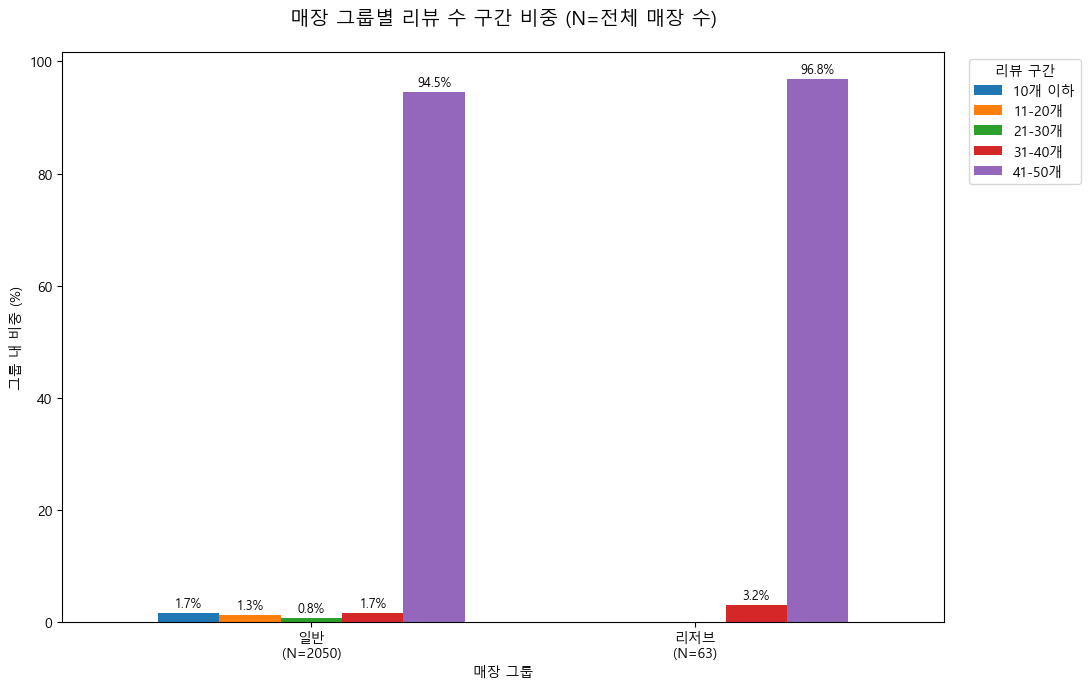

In [8]:
# H7 EDA - Step A. 데이터 신뢰성/구성 확인
# 매장 수(일반/리저브), 매장별 리뷰 수 분포(구간 비중) 확인

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import platform

# -----------------------------
# 0) 한글 폰트 설정 (깨짐 방지)
# -----------------------------
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# -----------------------------
# 1) 분석 대상 데이터 준비
# -----------------------------
# ✅ refined가 있으면 그대로 사용
# df = refined.copy()

# 혹시 변수명이 df라면 아래처럼
df = refined.copy()

# 필수 컬럼 체크
required_cols = ["store_id", "store_group"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f"필수 컬럼 없음: {missing}")

# store_group 표준화 (영문/한글 혼재 대응)
df["store_group_std"] = df["store_group"].astype(str).str.strip().replace({
    "general": "일반",
    "reserve": "리저브",
    "일반 매장": "일반",
    "리저브 매장": "리저브",
    "일반": "일반",
    "리저브": "리저브"
})

# 유효 그룹만 사용
df = df[df["store_group_std"].isin(["일반", "리저브"])].copy()

# -----------------------------
# 2) 매장별 리뷰 수 집계 (핵심)
# -----------------------------
# refined는 row-level 리뷰 데이터이므로, 매장별 리뷰 개수를 직접 계산
store_n = (
    df.groupby(["store_id", "store_group_std"], as_index=False)
      .size()
      .rename(columns={"size": "n_reviews"})
)

# 숫자형 안전 처리
store_n["n_reviews"] = pd.to_numeric(store_n["n_reviews"], errors="coerce")
store_n = store_n.dropna(subset=["n_reviews", "store_group_std"]).copy()

# 디버깅 확인
print("[매장 수]")
print(store_n["store_group_std"].value_counts())

print("\n[매장별 리뷰 수 요약]")
print(store_n.groupby("store_group_std")["n_reviews"].describe().round(2))

# -----------------------------
# 3) 리뷰 수 구간 생성
# -----------------------------
# 50개 제한 전처리 기준 반영
bins = [-1, 10, 20, 30, 40, 50]
labels = ["10개 이하", "11-20개", "21-30개", "31-40개", "41-50개"]

store_n["review_range"] = pd.cut(
    store_n["n_reviews"],
    bins=bins,
    labels=labels
)

# 혹시 50 초과값이 있으면 확인 (전처리 누락 검문소)
over_50 = store_n[store_n["n_reviews"] > 50]
if len(over_50) > 0:
    print(f"\n⚠️ 50개 초과 매장 수: {len(over_50)}")
    print(over_50.head())

# -----------------------------
# 4) 그룹명에 N 포함 라벨 만들기
# -----------------------------
group_counts = store_n["store_group_std"].value_counts()
n_gen = int(group_counts.get("일반", 0))
n_res = int(group_counts.get("리저브", 0))

label_map = {
    "일반": f"일반\n(N={n_gen})",
    "리저브": f"리저브\n(N={n_res})"
}
store_n["store_group_n"] = store_n["store_group_std"].map(label_map)

# 안전장치
store_n = store_n.dropna(subset=["store_group_n", "review_range"]).copy()

# -----------------------------
# 5) 피벗 테이블 생성
# -----------------------------
pivot_df = (
    store_n.groupby(["store_group_n", "review_range"], observed=False)
           .size()
           .unstack(fill_value=0)
)

# 보기 좋게 순서 고정
desired_index = [f"일반\n(N={n_gen})", f"리저브\n(N={n_res})"]
pivot_df = pivot_df.reindex(index=desired_index, columns=labels, fill_value=0)

print("\n[pivot_df 확인]")
print(pivot_df)

# -----------------------------
# 6) 그래프 출력
# -----------------------------
if pivot_df.empty or pivot_df.sum().sum() == 0:
    print("데이터 매칭 실패. store_group 값 / 구간 범위를 확인하세요.")
else:
    pivot_percent = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

    ax = pivot_percent.plot(kind="bar", figsize=(11, 7), width=0.8, rot=0)

    plt.title("매장 그룹별 리뷰 수 구간 비중 (N=전체 매장 수)", fontsize=14, pad=20)
    plt.xlabel("매장 그룹")
    plt.ylabel("그룹 내 비중 (%)")
    plt.legend(title="리뷰 구간", bbox_to_anchor=(1.02, 1), loc="upper left")

    # 막대 라벨
    for p in ax.patches:
        h = p.get_height()
        if pd.notna(h) and h > 0:
            ax.annotate(
                f"{h:.1f}%",
                (p.get_x() + p.get_width() / 2, h),
                ha="center",
                va="bottom",
                fontsize=9,
                xytext=(0, 2),
                textcoords="offset points"
            )

    plt.tight_layout()
    plt.show()

In [9]:
#위 그래프 해석

#  1. 데이터 분포와 표본의 신뢰성
# 일반 매장과 리저브 매장의 절대적인 수치 차이를 배제하기 위해 각 집단 내 리뷰 수 분포를 비교했습니다.
# 분석 결과, 일반 매장의 94.5%, 리저브 매장의 **96.8%**가 40~50개의 리뷰를 보유하고 있어, 두 집단 모두 통계적으로 충분한 표본을 확보했음을 확인했습니다.
# 특히 리저브 매장은 전체 매장 수(N=63)는 적으나, 리뷰 50개 구간에 집중된 비중이 일반 매장보다 높아 데이터의 일관성과 신뢰도가 매우 우수합니다.

# 2. 매장 단위 비율 표준화를 통한 편향 제거
# 매장마다 상이한 리뷰 수와 방문 규모로 인해 발생할 수 있는 편향을 방지하고자, 절대 수치가 아닌 **'매장별 방문 비중(Ratio)'**으로 데이터를 표준화했습니다.
# 이를 통해 규모가 큰 매장이 전체 평균을 왜곡하는 현상을 차단하고, 모든 매장이 분석 결과에 동일한 가중치로 기여하도록 설계했습니다.

# 3. 컷오프(30개) 설정 및 민감도 분석의 당위성
# 분석 결과에 미치는 영향을 배제하기 위해 추가로 " 민감도 분석" 진행

# 데이터의 약 95% 이상이 40~50개의 리뷰를 보유하고 있음에도 불구하고, 
# 결론의 강건성(Robustness)을 확인하기 위해 **'리뷰 30개 이상 매장'**을 대상으로 추가 민감도 분석을 수행했습니다.

# 30개를 선택한 이유:
# 통계적 원칙: 통계학에서 정규성을 가정할 수 있는 최소 표본 크기인 '30의 법칙'을 준수하여 학술적 근거를 확보했습니다.
# 왜곡 방지: 30개 미만일 경우 소수 리뷰에 의해 비율이 과도하게 튀는 '소수점의 왜곡'이 발생할 수 있으며, 
# 반대로 기준을 40개 이상으로 높일 경우 유효한 샘플이 불필요하게 손실될 우려가 있어 30개를 최적의 컷오프 지점으로 결정했습니다.


# 4. 결론의 강건성 확보
# 최종적으로, 신뢰도가 높은 데이터로 확인되나, 조금이라도 왜곡을 줄이기 위해 
# “매장 마다 다른 리뷰 수와 방문 규모의 편향을 줄이기 위해 매장 단위 비율로 표준화했고, 
# 추가로 리뷰 30개 이상 매장만 대상으로 민감도 분석을 수행해 결론의 강건성을 확인”
# 이를 통해, "50개 전체 분석"와 "30개 이상만 골라 분석" 결과가 일관되게 나온다면, 
# 우리 분석 결과는 표본 수에 상관없이 아주 강건하고 신뢰할 수 있는 결과임을 입증 가능

[전체 visit_time 분포]
visit_time
점심    62716
저녁    23467
아침    16159
Name: count, dtype: int64

[전체 day_type 분포]
day_type
주중    68698
주말    33644
Name: count, dtype: int64


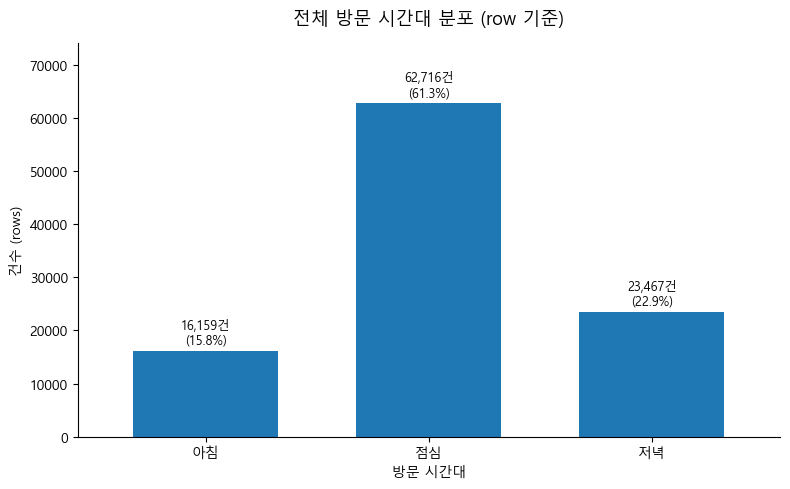

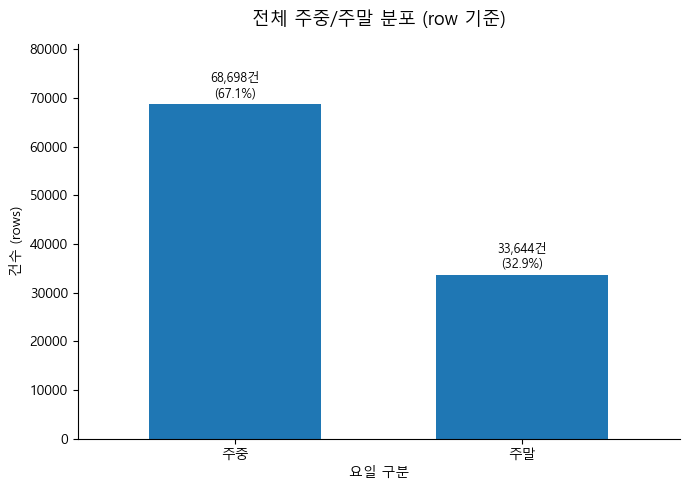

In [10]:
# Step B-1. 전체 분포 확인 (row-level) - 예쁘게 + 한글 폰트 포함

import pandas as pd
import matplotlib.pyplot as plt
import platform

# -----------------------------
# 0) 한글 폰트 설정 (깨짐 방지)
# -----------------------------
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# -----------------------------
# 1) 데이터 검문소 (값 확인)
# -----------------------------
print("[전체 visit_time 분포]")
print(df["visit_time"].value_counts(dropna=False))

print("\n[전체 day_type 분포]")
print(df["day_type"].value_counts(dropna=False))

# -----------------------------
# 2) visit_time 분포 그래프
# -----------------------------
vt_order = ["아침", "점심", "저녁"]
vt = df["visit_time"].astype(str).str.strip().value_counts().reindex(vt_order, fill_value=0)
vt_pct = (vt / vt.sum() * 100).round(1)

ax = vt.plot(kind="bar", figsize=(8, 5), rot=0, width=0.65)

plt.title("전체 방문 시간대 분포 (row 기준)", fontsize=13, pad=14)
plt.xlabel("방문 시간대")
plt.ylabel("건수 (rows)")

# y축 여유 공간 (라벨 안 잘리게)
ymax = vt.max() if len(vt) > 0 else 0
ax.set_ylim(0, ymax * 1.18 if ymax > 0 else 1)

# 값 + 비율 라벨
for p, cnt, pct in zip(ax.patches, vt.values, vt_pct.values):
    if cnt > 0:
        ax.annotate(
            f"{cnt:,}건\n({pct:.1f}%)",
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points"
        )

# 위/오른쪽 테두리 제거 (깔끔)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# -----------------------------
# 3) day_type 분포 그래프
# -----------------------------
dt_order = ["주중", "주말"]
dt = df["day_type"].astype(str).str.strip().value_counts().reindex(dt_order, fill_value=0)
dt_pct = (dt / dt.sum() * 100).round(1)

ax = dt.plot(kind="bar", figsize=(7, 5), rot=0, width=0.6)

plt.title("전체 주중/주말 분포 (row 기준)", fontsize=13, pad=14)
plt.xlabel("요일 구분")
plt.ylabel("건수 (rows)")

ymax = dt.max() if len(dt) > 0 else 0
ax.set_ylim(0, ymax * 1.18 if ymax > 0 else 1)

for p, cnt, pct in zip(ax.patches, dt.values, dt_pct.values):
    if cnt > 0:
        ax.annotate(
            f"{cnt:,}건\n({pct:.1f}%)",
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points"
        )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


[일반] 교차표 (건수)
visit_time     아침     점심     저녁
day_type                       
주중          11438  39840  15319
주말           4287  20975   7353

[일반] 행비율 (%)
visit_time    아침    점심    저녁
day_type                    
주중          17.2  59.8  23.0
주말          13.1  64.3  22.5

[리저브] 교차표 (건수)
visit_time   아침    점심   저녁
day_type                  
주중          296  1281  524
주말          138   620  271

[리저브] 행비율 (%)
visit_time    아침    점심    저녁
day_type                    
주중          14.1  61.0  24.9
주말          13.4  60.3  26.3


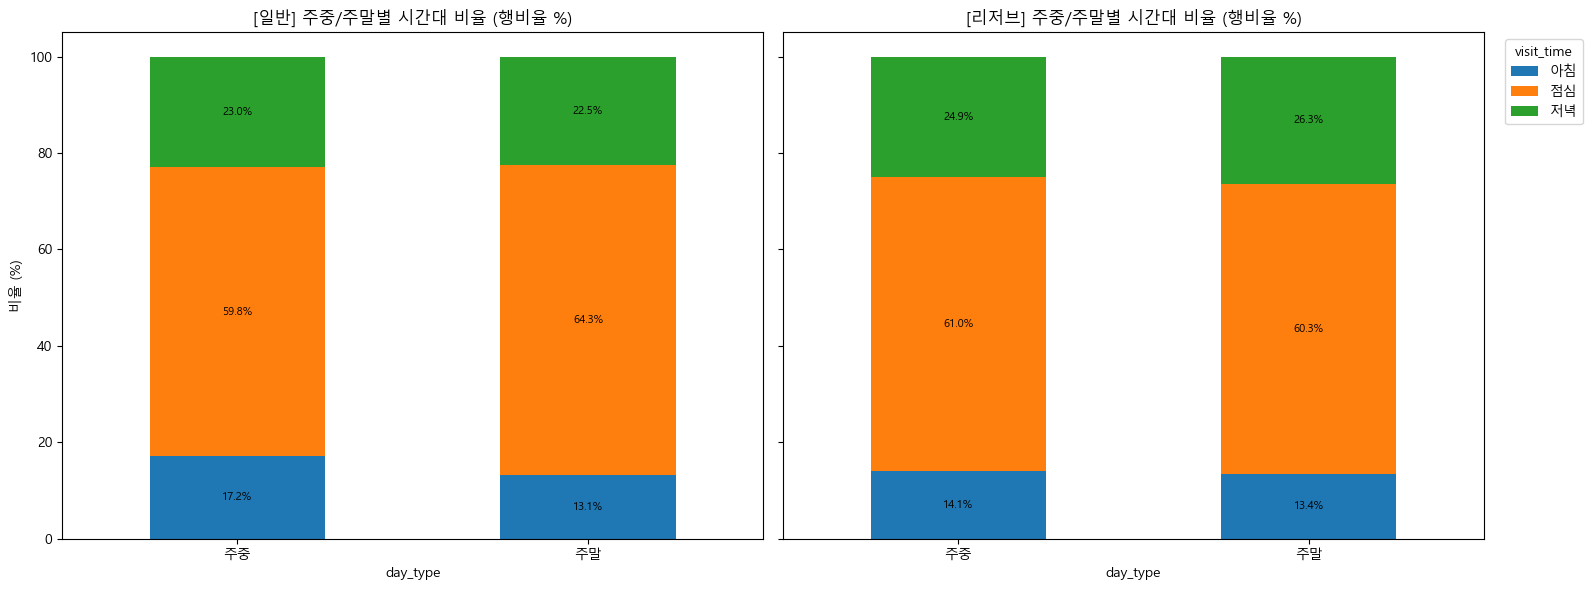

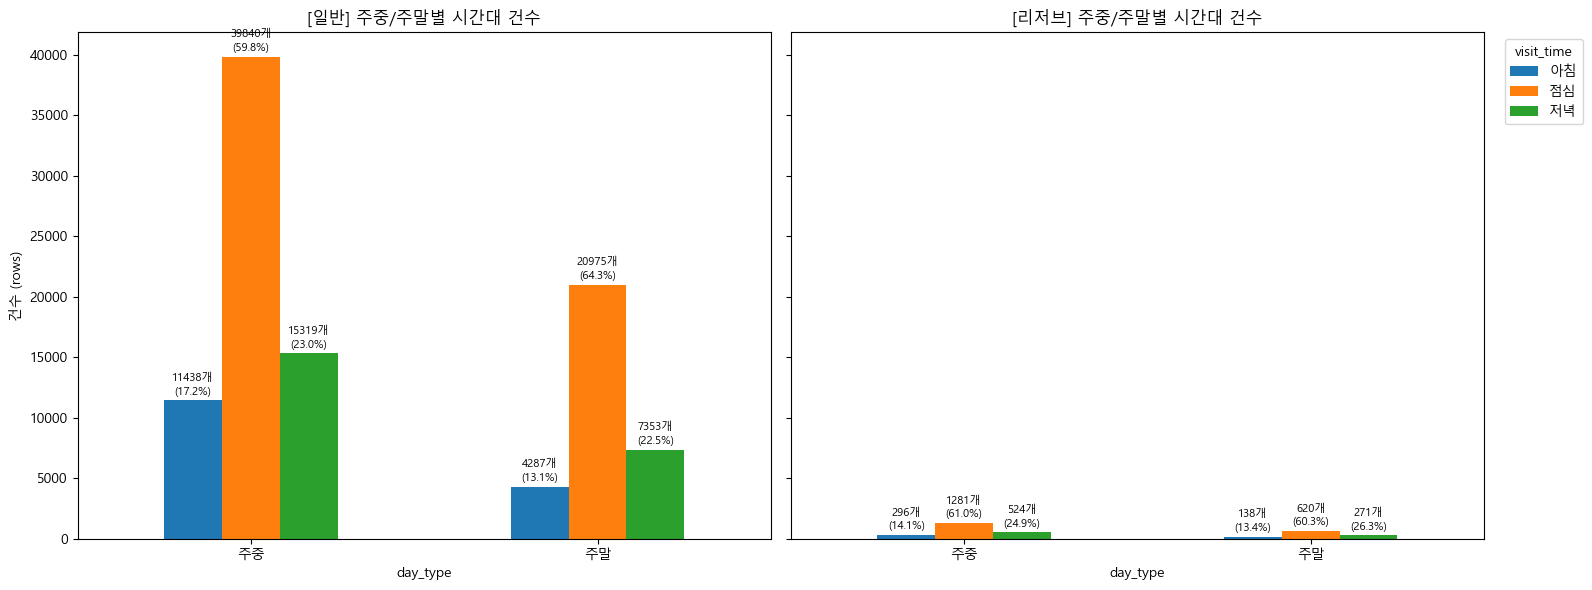

In [11]:
# Step B-3. 매장유형별 교차분포 비교 (일반 vs 리저브) - 양옆 비교

time_order = ["아침", "점심", "저녁"]
day_order = ["주중", "주말"]
group_order = ["일반", "리저브"]

# 각 그룹 교차표 준비
ct_dict = {}
ct_pct_dict = {}

for g in group_order:
    sub = df[df["store_group"] == g].copy()
    ct = pd.crosstab(sub["day_type"], sub["visit_time"]).reindex(
        index=day_order, columns=time_order, fill_value=0
    )
    ct_pct = ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0) * 100
    ct_dict[g] = ct
    ct_pct_dict[g] = ct_pct

    print(f"\n[{g}] 교차표 (건수)")
    print(ct)
    print(f"\n[{g}] 행비율 (%)")
    print(ct_pct.round(1))

# 1) 행비율 누적막대 (양옆)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, g in zip(axes, group_order):
    ct_pct = ct_pct_dict[g]
    ct_pct.plot(kind="bar", stacked=True, ax=ax, rot=0)

    ax.set_title(f"[{g}] 주중/주말별 시간대 비율 (행비율 %)")
    ax.set_xlabel("day_type")
    ax.set_ylabel("비율 (%)")

    # 내부 라벨
    for i, idx in enumerate(ct_pct.index):
        cum = 0
        for col in ct_pct.columns:
            val = ct_pct.loc[idx, col]
            if pd.notna(val) and val > 0:
                y = cum + val/2
                ax.text(i, y, f"{val:.1f}%", ha="center", va="center", fontsize=8)
                cum += val

axes[1].legend(title="visit_time", bbox_to_anchor=(1.02,1), loc="upper left")
axes[0].legend().remove()
plt.tight_layout()
plt.show()

# 2) 건수 막대 (양옆)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, g in zip(axes, group_order):
    ct = ct_dict[g]
    ct_pct = ct_pct_dict[g]

    ct.plot(kind="bar", ax=ax, rot=0)
    ax.set_title(f"[{g}] 주중/주말별 시간대 건수")
    ax.set_xlabel("day_type")
    ax.set_ylabel("건수 (rows)")

    n_rows = len(ct.index)
    for j, col in enumerate(ct.columns):
        for i, idx in enumerate(ct.index):
            p = ax.patches[j * n_rows + i]
            h = p.get_height()
            if h > 0:
                pct = ct_pct.loc[idx, col]
                ax.annotate(f"{int(h)}개\n({pct:.1f}%)",
                            (p.get_x()+p.get_width()/2, h),
                            ha="center", va="bottom", fontsize=8,
                            xytext=(0,2), textcoords="offset points")

axes[1].legend(title="visit_time", bbox_to_anchor=(1.02,1), loc="upper left")
axes[0].legend().remove()
plt.tight_layout()
plt.show()

[H7 후보 비교 요약표]


,store_group,candidate,candidate_label,count,sum,ratio_pct
4,리저브,is_morning,아침 비중,3130,434,13.87
5,일반,is_morning,아침 비중,99212,15725,15.85
8,리저브,is_evening,저녁 비중,3130,795,25.40
9,일반,is_evening,저녁 비중,99212,22672,22.85
6,리저브,is_lunch,점심 비중,3130,1901,60.73
7,일반,is_lunch,점심 비중,99212,60815,61.30
2,리저브,is_weekend,주말 비중,3130,1029,32.88
3,일반,is_weekend,주말 비중,99212,32615,32.87
16,리저브,is_weekend_morning,주말아침 비중,3130,138,4.41
17,일반,is_weekend_morning,주말아침 비중,99212,4287,4.32



[후보별 비율 피벗]


store_group,리저브,일반,"차이(리저브-일반, %p)"
candidate_label,,,
주중 비중,67.12,67.13,-0.01
주말 비중,32.88,32.87,0.01
아침 비중,13.87,15.85,-1.98
점심 비중,60.73,61.30,-0.57
저녁 비중,25.40,22.85,2.55
주중아침 비중,9.46,11.53,-2.07
주중점심 비중,40.93,40.16,0.77
주중저녁 비중,16.74,15.44,1.30
주말아침 비중,4.41,4.32,0.09


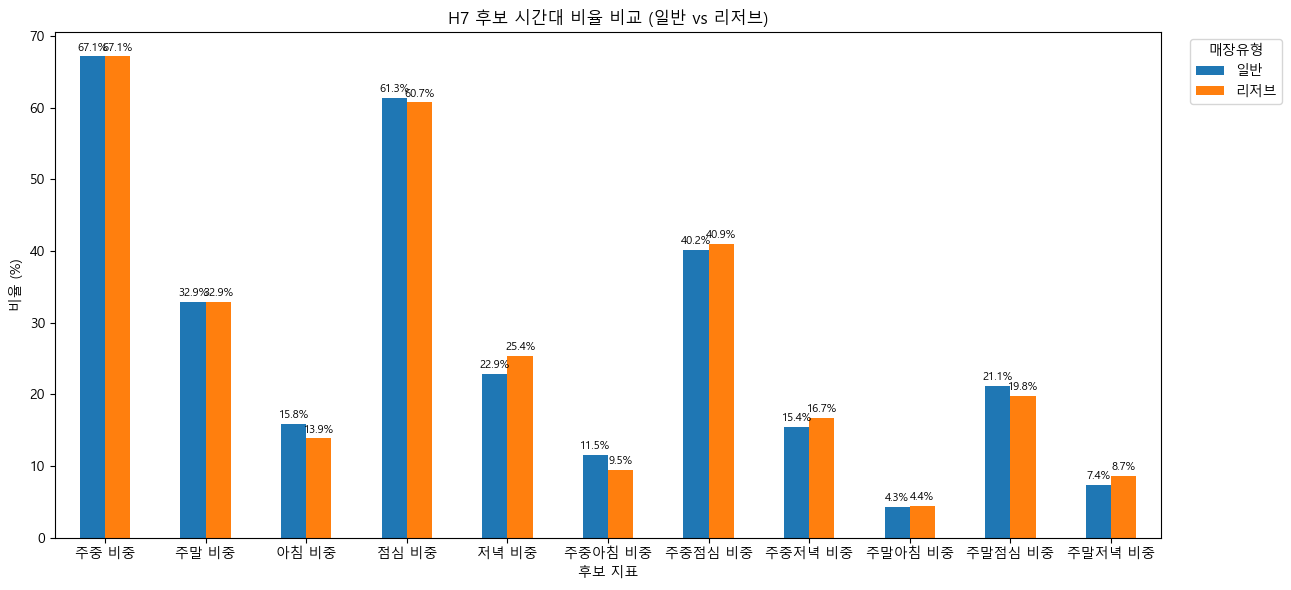

In [14]:
# Step B-4. H7 후보 비교 요약표 (일반 vs 리저브) - 확장 버전

# 후보 목록 (추가 포함)
candidate_map = {
    "is_weekday": "주중 비중",
    "is_weekend": "주말 비중",
    "is_morning": "아침 비중",          # ✅ 추가
    "is_lunch": "점심 비중",            # ✅ 추가
    "is_evening": "저녁 비중",
    "is_weekday_morning": "주중아침 비중", # ✅ 추가 (주중 오전)
    "is_weekday_lunch": "주중점심 비중",   # ✅ 추가
    "is_weekday_evening": "주중저녁 비중",
    "is_weekend_morning": "주말아침 비중",
    "is_weekend_lunch": "주말점심 비중",
    "is_weekend_evening": "주말저녁 비중",
}

# 안전장치: df에 없는 컬럼 자동 제외 (오타/누락 방지)
valid_candidate_map = {k: v for k, v in candidate_map.items() if k in df.columns}
missing_cols = [k for k in candidate_map.keys() if k not in df.columns]

if missing_cols:
    print("⚠️ df에 없는 후보 컬럼 (자동 제외됨):", missing_cols)

rows = []
for cand, label in valid_candidate_map.items():
    s = df.groupby("store_group")[cand].agg(["count", "sum", "mean"]).reset_index()
    s["ratio_pct"] = (s["mean"] * 100).round(2)
    s["candidate"] = cand
    s["candidate_label"] = label
    rows.append(s[["store_group", "candidate", "candidate_label", "count", "sum", "ratio_pct"]])

result = pd.concat(rows, ignore_index=True)

print("[H7 후보 비교 요약표]")
display(result.sort_values(["candidate_label", "store_group"]))

# 피벗 (그래프용)
ratio_pivot = result.pivot_table(
    index="candidate_label", columns="store_group", values="ratio_pct", aggfunc="first"
).fillna(0)

# 차이(리저브-일반)
if {"일반", "리저브"}.issubset(ratio_pivot.columns):
    ratio_pivot["차이(리저브-일반, %p)"] = (ratio_pivot["리저브"] - ratio_pivot["일반"]).round(2)

# 보기 순서 (추가 항목 포함)
desired_order = [
    "주중 비중", "주말 비중",
    "아침 비중", "점심 비중", "저녁 비중",
    "주중아침 비중", "주중점심 비중", "주중저녁 비중",
    "주말아침 비중", "주말점심 비중", "주말저녁 비중"
]
ratio_pivot = ratio_pivot.reindex([x for x in desired_order if x in ratio_pivot.index])

print("\n[후보별 비율 피벗]")
display(ratio_pivot.round(2))

# 비교 막대그래프
plot_cols = [c for c in ["일반", "리저브"] if c in ratio_pivot.columns]

ax = ratio_pivot[plot_cols].plot(kind="bar", figsize=(13, 6), rot=0)
plt.title("H7 후보 시간대 비율 비교 (일반 vs 리저브)")
plt.xlabel("후보 지표")
plt.ylabel("비율 (%)")
plt.legend(title="매장유형", bbox_to_anchor=(1.02, 1), loc="upper left")

for p in ax.patches:
    h = p.get_height()
    if pd.notna(h):
        ax.annotate(
            f"{h:.1f}%",
            (p.get_x() + p.get_width()/2, h),
            ha="center", va="bottom", fontsize=8,
            xytext=(0, 2), textcoords="offset points"
        )

plt.tight_layout()
plt.show()

In [ ]:
# Step C-1. 카이제곱 검정 (store_group × [day_type, visit_time 조합])
# 이 단계의 목적은 H7-0"일반 vs 리저브"에 따라 방문 패턴 분포가 다른가?? 확인 . 
# 여기서 방문 패턴은 연속형 값(평균, 점수)이 아니라,
# '주중_아침 / 주중_점심 / 주중_저녁 / 주말_아침 / 주말_점심 / 주말_저녁'
# 처럼 '범주(category)'로 나뉘는 값임.
#
# 즉, 지금 비교하는 변수 2개가 모두 범주형이다:
# 1) store_group  : 일반 / 리저브  (범주형)
# 2) slot_6       : 6개 시간대 조합  (범주형)
#
# 이런 경우에는 "두 범주형 변수가 서로 독립인지(=분포가 같은지)"를 검정하는
# 카이제곱 독립성 검정(Chi-square test of independence)이 적합함.

# 6개 조합 라벨 생성
df_test = df.copy()
df_test["slot_6"] = df_test["day_type"] + "_" + df_test["visit_time"]  # 예: 주말_저녁

ct_chi = pd.crosstab(df_test["store_group"], df_test["slot_6"]).reindex(
    index=["일반", "리저브"],
    columns=[
        "주중_아침", "주중_점심", "주중_저녁",
        "주말_아침", "주말_점심", "주말_저녁"
    ],
    fill_value=0
)

print("[카이제곱용 분할표]")
print(ct_chi)

chi2, p, dof, expected = chi2_contingency(ct_chi)

print("\n[카이제곱 검정 결과]")
print(f"chi2 = {chi2:.4f}")
print(f"p-value = {p:.6f}")
print(f"dof = {dof}")

# 기대빈도 확인 (너무 작은 칸 있는지)
expected_df = pd.DataFrame(expected, index=ct_chi.index, columns=ct_chi.columns)
print("\n[기대빈도 최소값]")
print(expected_df.min().min())

[카이제곱용 분할표]
slot_6       주중_아침  주중_점심  주중_저녁  주말_아침  주말_점심  주말_저녁
store_group                                          
일반           11438  39840  15319   4287  20975   7353
리저브            296   1281    524    138    620    271

[카이제곱 검정 결과]
chi2 = 24.0661
p-value = 0.000211
dof = 5

[기대빈도 최소값]
135.3330011139122


In [ ]:
# H0(귀무가설): store_group과 slot_6은 독립이다.
#              -> 일반/리저브의 시간대 분포 차이가 없다 (우연한 차이)
#
# H1(대립가설): store_group과 slot_6은 독립이 아니다.
#              -> 일반/리저브의 시간대 분포 차이가 있다 (채택)
# ------------------------------------------------------------
#
# [중요] 이 검정은 "분포 차이 존재 여부"를 보는 검정이다.
# - 즉, '차이가 있냐/없냐'를 먼저 확인하는 단계
# - 아직 "리저브가 일반보다 주말저녁 비중이 더 높다"를 직접 검정하는 단계는 아님
#
# 그래서 이 단계는 H7을 바로 확정하는 검정이 아니라,
# "시간대 분포 차이가 전체적으로 존재하는지"를 확인하는 선행 검정 역할을 함.

# 해석:“두 그룹의 시간대 분포가 동일하다고 보기 어렵다”(차이가 어딘지는 아직 추가 해석 필요)
#
# 이후 H7(방향성 가설: 리저브 > 일반 in 주말저녁)은
# - 비율 비교 (주말저녁 비중 비교)
# - 또는 로지스틱 회귀/비율 검정
# 같은 방식으로 별도 확인하는 것이 더 적절.

In [18]:
# Step C-2. 2표본 비율검정 (단측: 리저브 > 일반)

def one_sided_prop_test(df_in, col, label):
    # 집단별 성공수/전체수
    agg = df_in.groupby("store_group")[col].agg(["sum", "count"]).reindex(["일반", "리저브"])
    if agg.isna().any().any():
        return {
            "지표": label, "일반 비율(%)": np.nan, "리저브 비율(%)": np.nan,
            "차이(리저브-일반, %p)": np.nan, "z통계량": np.nan, "p값(단측)": np.nan
        }

    count = np.array([agg.loc["일반", "sum"], agg.loc["리저브", "sum"]], dtype=float)
    nobs  = np.array([agg.loc["일반", "count"], agg.loc["리저브", "count"]], dtype=float)

    z_stat, p_two = proportions_ztest(count=count, nobs=nobs, alternative="two-sided")

    # 단측(리저브 > 일반) p값으로 변환
    # statsmodels 입력 순서: [일반, 리저브]
    # z > 0 이면 리저브 비율이 더 큰 방향
    if z_stat >= 0:
        p_one = p_two / 2
    else:
        p_one = 1 - (p_two / 2)

    ratio_gen = count[0] / nobs[0] * 100
    ratio_res = count[1] / nobs[1] * 100

    return {
        "지표": label,
        "일반 비율(%)": round(ratio_gen, 2),
        "리저브 비율(%)": round(ratio_res, 2),
        "차이(리저브-일반, %p)": round(ratio_res - ratio_gen, 2),
        "z통계량": round(float(z_stat), 4),
        "p값(단측)": round(float(p_one), 6),
    }

# 검정 후보 (네 상황에 맞게 조정 가능)
test_candidates = [
    ("is_weekend", "H7-1 후보: 주말 비중"),
    ("is_evening", "보조 후보: 저녁 비중"),
    ("is_weekend_lunch", "H7-2 후보: 주말점심 비중"),
    ("is_weekend_evening", "H7-2 후보: 주말저녁 비중"),
    ("is_weekday_evening", "비교 후보: 주중저녁 비중"),
]

test_rows = []
for col, label in test_candidates:
    test_rows.append(one_sided_prop_test(df, col, label))

test_table = pd.DataFrame(test_rows)
print("[2표본 비율검정 결과]")
display(test_table)

[2표본 비율검정 결과]


,지표,일반 비율(%),리저브 비율(%),"차이(리저브-일반, %p)",z통계량,p값(단측)
0,H7-1 후보: 주말 비중,32.87,32.88,0.00,-0.0016,0.500632
1,보조 후보: 저녁 비중,22.85,25.40,2.55,-3.3378,0.999578
2,H7-2 후보: 주말점심 비중,21.14,19.81,-1.33,1.8000,0.035933
3,H7-2 후보: 주말저녁 비중,7.41,8.66,1.25,-2.6155,0.995545
4,비교 후보: 주중저녁 비중,15.44,16.74,1.30,-1.9805,0.976178


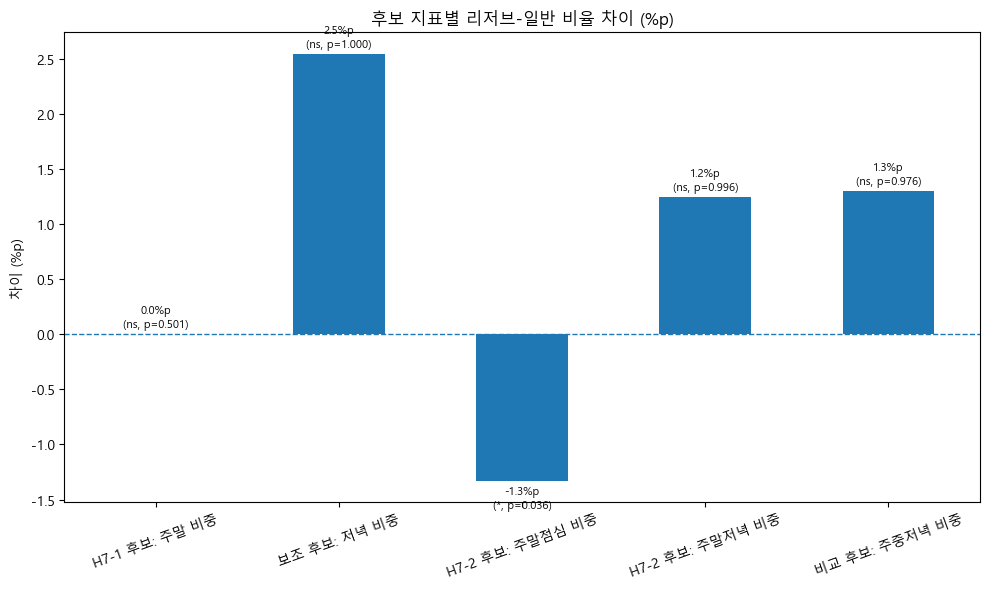

In [19]:
# Step C-3. 검정 결과 시각화 (차이 %p + 유의성)

plot_tbl = test_table.copy()

ax = plot_tbl.plot(
    x="지표", y="차이(리저브-일반, %p)",
    kind="bar", figsize=(10, 6), legend=False, rot=20
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("후보 지표별 리저브-일반 비율 차이 (%p)")
plt.xlabel("")
plt.ylabel("차이 (%p)")

for i, row in plot_tbl.iterrows():
    v = row["차이(리저브-일반, %p)"]
    p = row["p값(단측)"]

    if pd.isna(p):
        sig = "NA"
    elif p < 0.001:
        sig = "***"
    elif p < 0.01:
        sig = "**"
    elif p < 0.05:
        sig = "*"
    else:
        sig = "ns"

    ax.annotate(
        f"{v:.1f}%p\n({sig}, p={p:.3f})",
        (i, v),
        ha="center",
        va="bottom" if v >= 0 else "top",
        fontsize=8,
        xytext=(0, 3 if v >= 0 else -3),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

In [ ]:
# 해석: 

# 주중/주말 비중은 일반/리저브가 거의 유사

# 반면 저녁 비중은 리저브가 상대적으로 높게 나타나는 경향

# 주말저녁 비중도 리저브가 약간 높지만, 통계적으로 강하게 지지되진 않음

# ✅ 그래서 결론을 이렇게 가져감:

# ‘주말’ 자체보다는 ‘저녁 시간대’가 더 의미 있는 구분축

# 주말저녁은 세부 패턴 후보로는 의미 있지만, 핵심 가설로 확정하기엔 약함


# H7-0"일반 vs 리저브"에 따라 방문 패턴 분포가 다른가??
# H7-1 (메인) : 리저브 매장은 일반 매장보다 저녁 시간대 방문 비중이 높을 것이다.
# H7-2 (세부 가설)  : 리저브 매장은 일반 매장보다 주말 저녁 방문 비중이 높을 것이다.


In [20]:
# 최종 해석용 체크 포인트 출력

print("=== 해석 체크리스트 ===")
print("1) 카이제곱 p < 0.05 이면: 일반/리저브의 시간대 분포가 전체적으로 다름")
print("2) H7-1 후보(주말 비중): 리저브 비율 > 일반 비율 + 단측 p<0.05 이면 채택 근거")
print("3) H7-2 후보(주말점심/주말저녁): 둘 중 차이와 유의성이 더 좋은 쪽 선택")
print("4) 저녁 단독(is_evening)은 보조지표로 해석")
print("5) 표본(건수) 너무 작은 조합은 '참고 수준'이라고 명시")

=== 해석 체크리스트 ===
1) 카이제곱 p < 0.05 이면: 일반/리저브의 시간대 분포가 전체적으로 다름
2) H7-1 후보(주말 비중): 리저브 비율 > 일반 비율 + 단측 p<0.05 이면 채택 근거
3) H7-2 후보(주말점심/주말저녁): 둘 중 차이와 유의성이 더 좋은 쪽 선택
4) 저녁 단독(is_evening)은 보조지표로 해석
5) 표본(건수) 너무 작은 조합은 '참고 수준'이라고 명시
